In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from helpers import *
plt.rcParams["figure.figsize"] = (12, 6)

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

## Load Data

In [2]:
data_path = "../btc_data/BTCUSD_1m_Binance.csv"

btc_df = pd.read_csv(data_path, nrows=1)
display(btc_df.head())

btc_df = pd.read_csv(data_path, usecols=["Open time", "Close", "Volume"])
display(btc_df.head())

# rename columns
btc_df.columns = ["timestamp", "close_price", "volume"]
display(btc_df.head())

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183,2017-08-17 04:00:59.999,7564.906851,3.0,0.075183,320.390851,0.0


,Open time,Close,Volume
0,2017-08-17 04:00:00,4261.48,1.775183
1,2017-08-17 04:01:00,4261.48,0.000000
2,2017-08-17 04:02:00,4280.56,0.261074
3,2017-08-17 04:03:00,4261.48,0.012008
4,2017-08-17 04:04:00,4261.48,0.140796


,timestamp,close_price,volume
0,2017-08-17 04:00:00,4261.48,1.775183
1,2017-08-17 04:01:00,4261.48,0.000000
2,2017-08-17 04:02:00,4280.56,0.261074
3,2017-08-17 04:03:00,4261.48,0.012008
4,2017-08-17 04:04:00,4261.48,0.140796


In [3]:
df_daily = (
    btc_df
    .assign(timestamp=pd.to_datetime(btc_df["timestamp"])) # make timestamp as datetime column
    .set_index("timestamp") # set timestamp as index
    .sort_index()           # sort indices according to date
    .resample("D")          # resample data frequency
    .agg({
        "close_price": "last",   # end-of-day price
        "volume": "sum"          # total daily volume
    })
)


display(df_daily.head())

print(f"Count of missing values:\n{df_daily.isna().sum()}")

,close_price,volume
timestamp,,
2017-08-17,4285.08,795.150377
2017-08-18,4108.37,1199.888264
2017-08-19,4139.98,381.309763
2017-08-20,4086.29,467.083022
2017-08-21,4016.00,691.743060


Count of missing values:
close_price    0
volume         0
dtype: int64


### Data Exploration

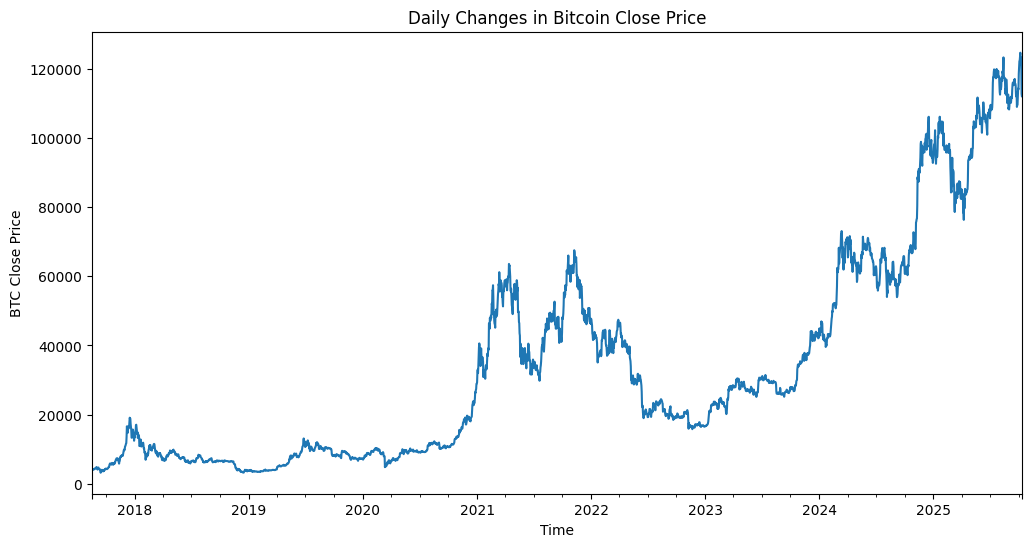

In [4]:
# plot temperature againest time
df_daily["close_price"].plot()
plt.title("Daily Changes in Bitcoin Close Price")
plt.xlabel("Time")
plt.ylabel("BTC Close Price")
plt.show()

From the graph of the daily changes in Bitcoin’s closing price, we see an upward trend, as prices have started to increase over the past five years. Regarding patterns, fluctuations have become larger over time. In the earlier years (2018–2020), the changes were small, while in the later years (2024–2025), similar movements appear much bigger, indicating that the variability is not constant. From this plot, it is difficult to clearly identify repeating patterns. On the other hand, there are longer-term rises and falls around 2021 and late 2024, which are likely influenced by broader market or economic conditions.

From this point, we can analyze the series components to determine the seasonality and trend behavior over time.

### Data Preparation

In [5]:
# creating features
df_daily["day_of_week"] = df_daily.index.day_of_week
df_daily["month"] = df_daily.index.month
df_daily["day_of_year"] = df_daily.index.day_of_year
df_daily["day_name"] = df_daily.index.day_name()
df_daily["is_weekend"] = df_daily["day_name"].isin(["Saturday", "Sunday"]).astype(int)

display(df_daily.head())

# drop day_name column
df_daily.drop(columns="day_name", inplace=True)
display(df_daily.head())

,close_price,volume,day_of_week,month,day_of_year,day_name,is_weekend
timestamp,,,,,,,
2017-08-17,4285.08,795.150377,3,8,229,Thursday,0
2017-08-18,4108.37,1199.888264,4,8,230,Friday,0
2017-08-19,4139.98,381.309763,5,8,231,Saturday,1
2017-08-20,4086.29,467.083022,6,8,232,Sunday,1
2017-08-21,4016.00,691.743060,0,8,233,Monday,0


,close_price,volume,day_of_week,month,day_of_year,is_weekend
timestamp,,,,,,
2017-08-17,4285.08,795.150377,3,8,229,0
2017-08-18,4108.37,1199.888264,4,8,230,0
2017-08-19,4139.98,381.309763,5,8,231,1
2017-08-20,4086.29,467.083022,6,8,232,1
2017-08-21,4016.00,691.743060,0,8,233,0


In [6]:
# we will use lag 1, lag 3, lag 7 as experiment
lags = [1, 3, 7]
rollings = [7, 14, 30]

# creating lag features (model history)
for lag in lags:
    df_daily = create_lag_feature(lag, df_daily, "close_price")

# creating rolling window (model overall pattern)
for rolling in rollings:
    df_daily = create_rolling_feature(df_daily, "close_price", rolling, "mean", f"rolling_mean_{str(rolling)}")
    df_daily = create_rolling_feature(df_daily, "close_price", rolling, "std", f"rolling_std_{str(rolling)}")

display(df_daily.head())

,close_price,volume,day_of_week,month,day_of_year,is_weekend,lag_1,lag_3,lag_7,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30
timestamp,,,,,,,,,,,,,,,
2017-08-17,4285.08,795.150377,3,8,229,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-18,4108.37,1199.888264,4,8,230,0,4285.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-19,4139.98,381.309763,5,8,231,1,4108.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-20,4086.29,467.083022,6,8,232,1,4139.98,4285.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-21,4016.00,691.743060,0,8,233,0,4086.29,4108.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For cyclic, repeating time data such as days (0–6) and months (1–12), we need to convert the linear, non-repeating day_of_week and month columns into cyclic data. This allows the model to understand that the gap between December (12) and January (1) is the same as the gap between January (1) and February (2). To achieve this, we will add new feature for each of these columns, using sine and cosine transformations.

In [7]:
# Day of week
df_daily["day_of_week_sin"] = np.sin(2 * np.pi * df_daily["day_of_week"] / 7)
df_daily["day_of_week_cos"] = np.cos(2 * np.pi * df_daily["day_of_week"] / 7)

# Month
df_daily["month_sin"] = np.sin(2 * np.pi * df_daily["month"] / 12)
df_daily["month_cos"] = np.cos(2 * np.pi * df_daily["month"] / 12)

display(df_daily.head())

,close_price,volume,day_of_week,month,day_of_year,is_weekend,lag_1,lag_3,lag_7,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,day_of_week_sin,day_of_week_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,,,,,,
2017-08-17,4285.08,795.150377,3,8,229,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.433884,-0.900969,-0.866025,-0.5
2017-08-18,4108.37,1199.888264,4,8,230,0,4285.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.433884,-0.900969,-0.866025,-0.5
2017-08-19,4139.98,381.309763,5,8,231,1,4108.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.974928,-0.222521,-0.866025,-0.5
2017-08-20,4086.29,467.083022,6,8,232,1,4139.98,4285.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.781831,0.623490,-0.866025,-0.5
2017-08-21,4016.00,691.743060,0,8,233,0,4086.29,4108.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,-0.866025,-0.5


In [8]:
# Inspect how many data we will lose

# original length
original_len = len(df_daily)

# drop NaNs
df_clean = df_daily.dropna()

# new length
clean_len = len(df_clean)

# lost rows
lost_rows = original_len - clean_len
lost_pct = lost_rows / original_len * 100

print(f"Original rows: {original_len}")
print(f"Rows after dropna: {clean_len}")
print(f"Rows lost: {lost_rows} ({lost_pct:.2f}%)")

Original rows: 2978
Rows after dropna: 2949
Rows lost: 29 (0.97%)


In [9]:
# drop NANs
df_daily = df_daily.dropna()
display(df_daily.head())

,close_price,volume,day_of_week,month,day_of_year,is_weekend,lag_1,lag_3,lag_7,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,day_of_week_sin,day_of_week_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,,,,,,
2017-09-15,3700.00,1968.866492,4,9,258,0,3189.02,4163.72,4282.80,3942.154286,383.311840,4188.361429,389.978923,4258.668000,322.460371,-0.433884,-0.900969,-1.0,-1.836970e-16
2017-09-16,3714.95,1297.563953,5,9,259,1,3700.00,3944.69,4258.81,3864.460000,363.011463,4134.276429,399.973246,4239.663667,337.308657,-0.974928,-0.222521,-1.0,-1.836970e-16
2017-09-17,3699.99,682.171210,6,9,260,1,3714.95,3189.02,4130.37,3802.977143,346.541290,4076.484286,400.104766,4226.051000,350.762090,-0.781831,0.623490,-1.0,-1.836970e-16
2017-09-18,4035.01,1030.006455,0,9,261,0,3699.99,3700.00,4208.47,3778.197143,317.716238,4071.834286,400.187354,4222.552000,352.171021,0.000000,1.000000,-1.0,-1.836970e-16
2017-09-19,3910.04,902.332129,1,9,262,0,4035.01,3714.95,4163.72,3741.957143,278.454948,4039.232143,392.862818,4216.677000,355.972169,0.781831,0.623490,-1.0,-1.836970e-16


### Chronological Train/Test Split

In [10]:
X = df_daily.drop(columns=["volume", "close_price"])
y = df_daily["close_price"]

print(f"Number of features: {X.shape[1]}")
print(f"Target variable: {y.name}")
print(f"\nSample features:")
display(X.head())
print(f"\nSample target:\n")
display(y.head())

Number of features: 17
Target variable: close_price

Sample features:


,day_of_week,month,day_of_year,is_weekend,lag_1,lag_3,lag_7,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,day_of_week_sin,day_of_week_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,,,,
2017-09-15,4,9,258,0,3189.02,4163.72,4282.80,3942.154286,383.311840,4188.361429,389.978923,4258.668000,322.460371,-0.433884,-0.900969,-1.0,-1.836970e-16
2017-09-16,5,9,259,1,3700.00,3944.69,4258.81,3864.460000,363.011463,4134.276429,399.973246,4239.663667,337.308657,-0.974928,-0.222521,-1.0,-1.836970e-16
2017-09-17,6,9,260,1,3714.95,3189.02,4130.37,3802.977143,346.541290,4076.484286,400.104766,4226.051000,350.762090,-0.781831,0.623490,-1.0,-1.836970e-16
2017-09-18,0,9,261,0,3699.99,3700.00,4208.47,3778.197143,317.716238,4071.834286,400.187354,4222.552000,352.171021,0.000000,1.000000,-1.0,-1.836970e-16
2017-09-19,1,9,262,0,4035.01,3714.95,4163.72,3741.957143,278.454948,4039.232143,392.862818,4216.677000,355.972169,0.781831,0.623490,-1.0,-1.836970e-16



Sample target:



timestamp
2017-09-15    3700.00
2017-09-16    3714.95
2017-09-17    3699.99
2017-09-18    4035.01
2017-09-19    3910.04
Freq: D, Name: close_price, dtype: float64

In [11]:
# number of rows
n = len(df_daily)

# test size = 20%
train_size = int(n * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2359, 17)
y_train shape: (2359,)
X_test shape: (590, 17)
y_test shape: (590,)


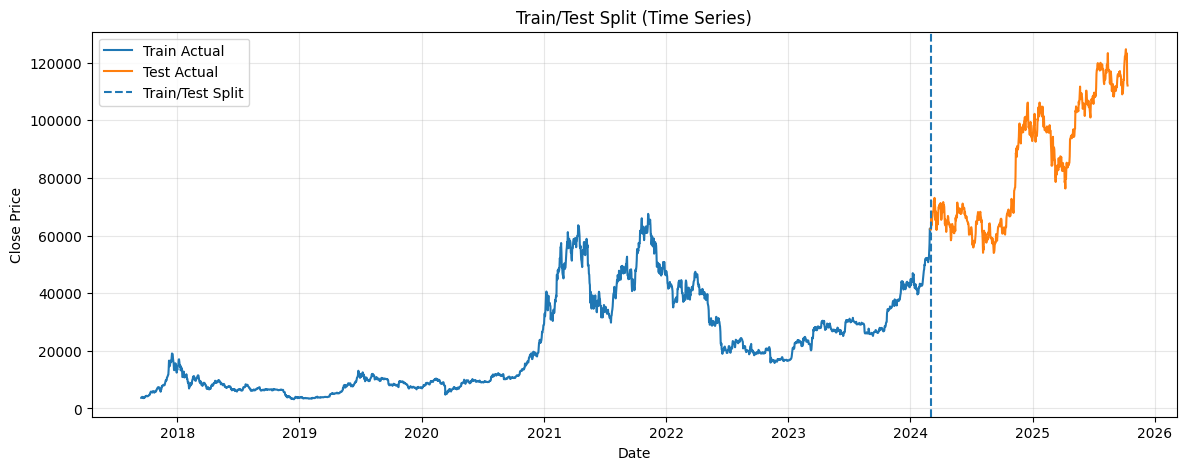

In [12]:
plot_time_series_split(X_train, y_train, X_test, y_test)

## Modeling

First we will try some Tree based models, the 2 models we will try are **Random Forest** and **XGBoost** these 2 models will be used as base model to see how they will fit to out complex data.

### Random Forest

In [13]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
y_train_predictions = rf_model.predict(X_train)
y_test_predictions = rf_model.predict(X_test)

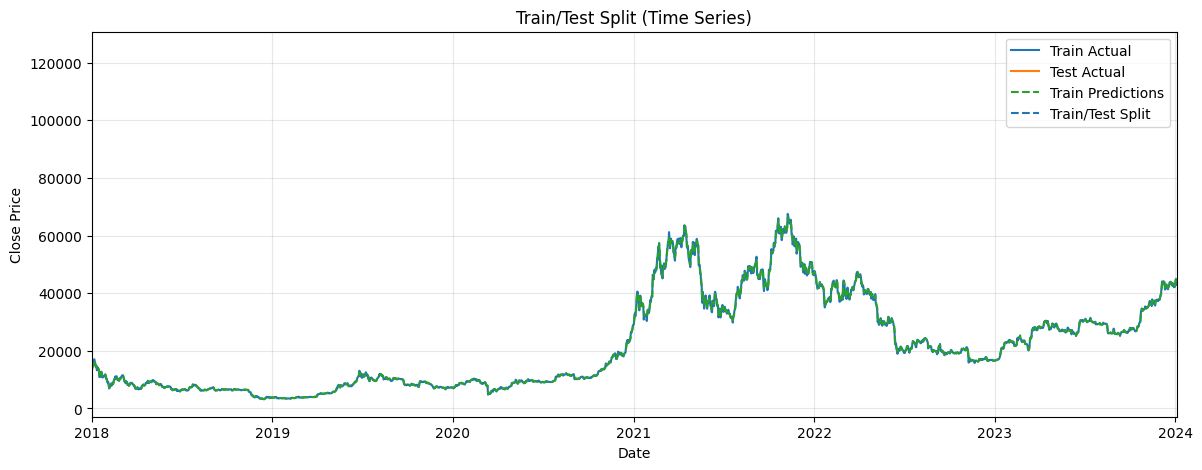

In [14]:
# plot train prediction 
plot_time_series_split(
    X_train, y_train,
    X_test, y_test,
    y_train_pred=y_train_predictions,
    zoom=True,
    zoom_range=("2018-01-01", "2024-01-04")
)

By using the Random Forest model with the default parameters, without customization or tuning, we can see that the model fitted the training data well, capturing the sudden increase in Bitcoin close price that happened in the period between 2021 and the beginning of 2023.

Now we will plot the test predictions and see how the model will perfrom on test data.

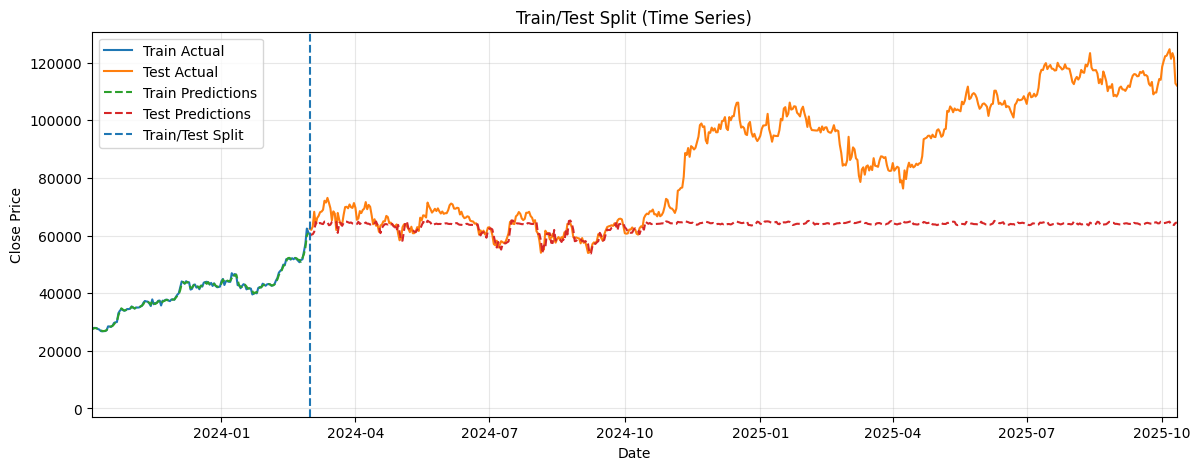

In [15]:
# forecast on test set
plot_time_series_split(
    X_train, y_train,
    X_test, y_test,
    y_pred=y_test_predictions,
    y_train_pred=y_train_predictions,
    zoom=True,
    zoom_pct=0.25
)


From the graph, the Random Forest model with default hyperparameters succeeded in approximately predicting the close price at the start of 2024 until October of the same year, as the Random Forest model does not predict values outside the range it encountered during training. So, when the close prices started to increase massively after the beginning of 2025, the model stabilized and did not exceed that constant value. Also, we can see that the predicted close prices in March, May, and June have not been captured well, as the close prices were slightly higher than the maximum value the model was trained on or saw during training. Therefore, we can fine-tune the model hyperparameters so that it can achieve better performance, and later on, we will use an approach to overcome the problem of **extrapolation**.

In [16]:
# Random Forest hyperparameters
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [False, True]
}

# XGBoost hyperparameters
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1]
}


In [17]:
# Random Forest
best_rf, rf_params, rf_results = time_series_grid_search(
    X_train, y_train, 
    model_type="rf", 
    param_grid=rf_param_grid
)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params for rf: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best neg_mean_squared_error: -169502695.57325545


In [18]:
# XGBoost
best_xgb, xgb_params, xgb_results = time_series_grid_search(
    X_train, y_train, 
    model_type="xgb", 
    param_grid=xgb_param_grid
)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params for xgb: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best neg_mean_squared_error: -179002347.41406846


After Finding the best parameters for **Random Forest** and **XGBoost** we will fit both of them on the train set and compare between them using performance metrics to decide which base model we will use.

In [19]:
models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

comparison_df, preds = compare_models(models, X_train, y_train, X_test, y_test)
display(comparison_df)

,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
Model,,,,,,
Random Forest,343.667257,596.058035,0.998648,22741.208501,29773.652362,-1.083333
XGBoost,471.229265,765.303201,0.997770,24430.846110,31651.239893,-1.354376


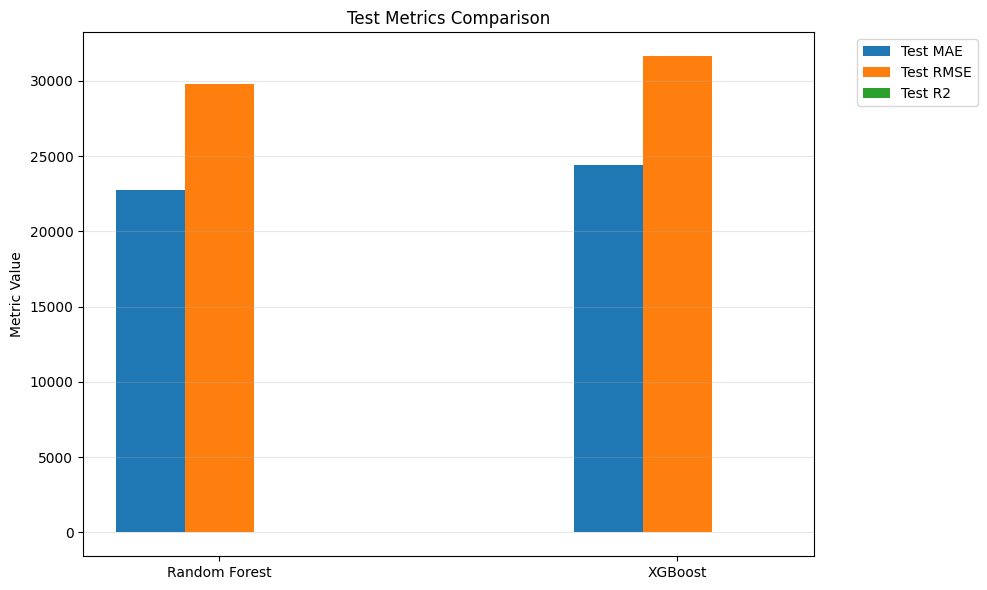

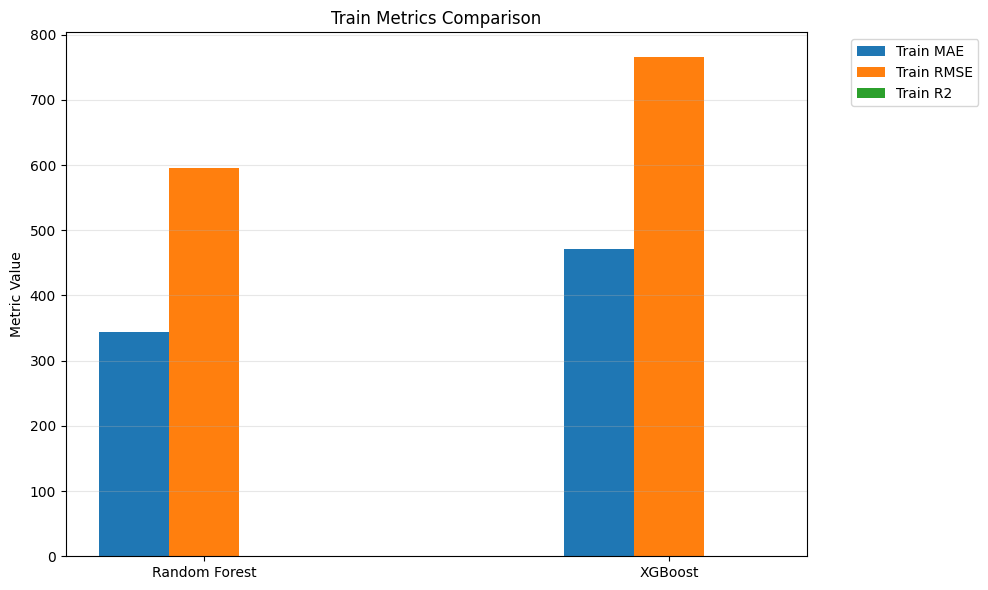

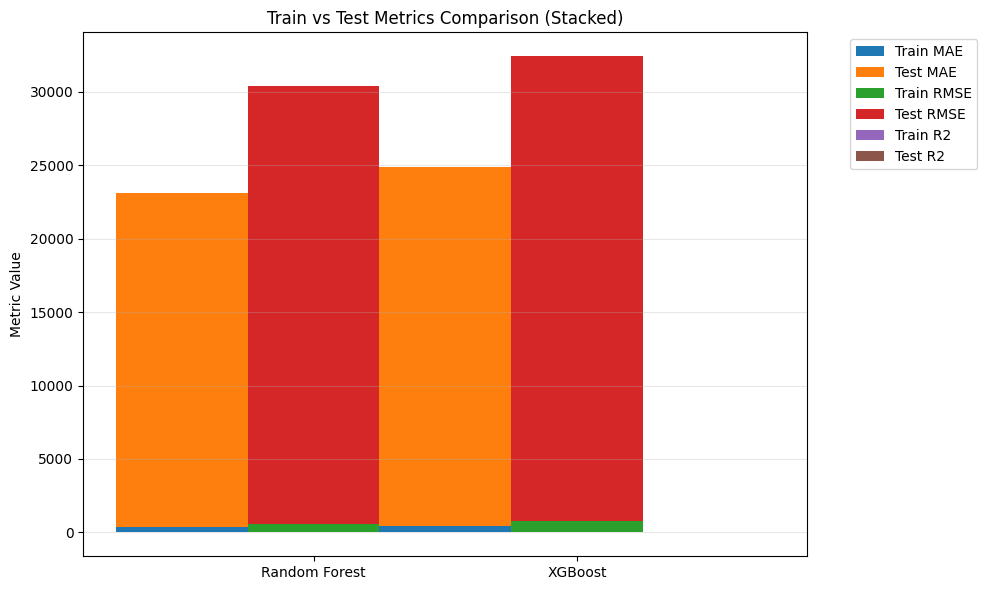

In [20]:
# Only Test metrics
plot_model_metrics(comparison_df, set_type="test", metrics=["MAE","RMSE","R2"])

# Only Train metrics
plot_model_metrics(comparison_df, set_type="train", metrics=["MAE","RMSE","R2"])

# Both Train & Test
plot_model_metrics(comparison_df, stacked=True, metrics=["MAE","RMSE","R2"])

In the plot (Train Metrics), both models look very good. The MAE for Random Forest is around 343, while XGBoost is lower at about 471.
For RMSE, XGBoost also shows a tighter fit during training.

The reason behind this is that the models are memorizing the data they were trained on, so the error appears small compared to the test set. However, when the model faces unseen data (close prices) that are different from what it was trained on, the error increases significantly.

In the test set, the MAE for both models increases to more than 22,000.
This means that, on average, the prediction error is over $22,000 per day.

For RMSE (Orange), the value is close to 30,000.
Since RMSE squares the errors, this high value indicates that there are very large errors in some cases.

Finally, the model is too sensitive to the training data and cannot generalize to new trends.

Tree-based models work as interpolators.
They are good at predicting values within the range of the data they have seen,
but they cannot forecast trends that go beyond that range.

In [21]:
y_train_predictions_rf = best_rf.predict(X_train)
y_train_predictions_xgb = best_xgb.predict(X_train)

y_test_predictions_rf = best_rf.predict(X_test)
y_test_predictions_xgb = best_xgb.predict(X_test)

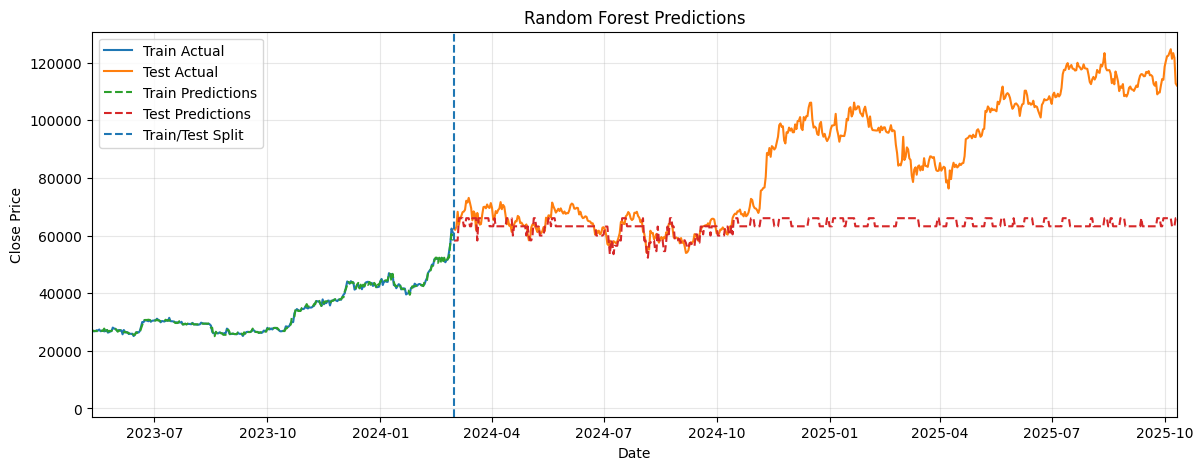

In [22]:
plot_time_series_split(
    X_train, y_train,
    X_test, y_test,
    y_pred=y_test_predictions_rf,
    y_train_pred=y_train_predictions_rf,
    zoom=True,
    zoom_pct=0.30,
    title="Random Forest Predictions"
)

In this graph, the performance of the Random Forest (RF) model applied to Bitcoin (BTC) closing prices looks almost perfect during the training phase. However, the model fails to capture the upward trend, which is an issue known as extrapolation, since decision tree–based models cannot handle non-stationary data.

During the training period, the model predictions are very close to the actual prices, and it almost looks like a perfect fit. However, in the test period (2024–2026), at the beginning of 2024, the predictions stay within a fixed range (around $60,000). When Bitcoin prices start increasing significantly, the model does not follow this upward movement and instead remains almost flat, as it can only predict values within the range it has already seen.

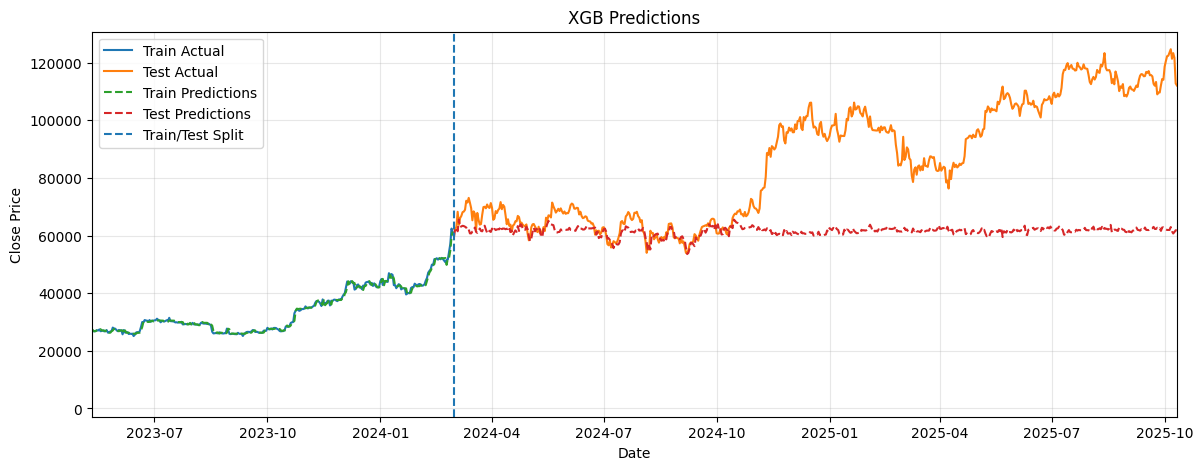

In [23]:
plot_time_series_split(
    X_train, y_train,
    X_test, y_test,
    y_pred=y_test_predictions_xgb,
    y_train_pred=y_train_predictions_xgb,
    zoom=True,
    zoom_pct=0.30,
    title="XGB Predictions"
)

The XGBoost (Extreme Gradient Boosting) model behaves almost the same as the Random Forest model, so using a more advanced tree-based model does not solve the main problem, which is dealing with non-stationary data.

During training, the model predictions match the actual prices almost perfectly.

This happens because XGBoost builds trees step by step to reduce the error. As a result, it becomes very easy for the model to memorize the training data, and we can observe this from the performance metrics and the graph above, where the loss gap between the training and testing is larger compared to the Random Forest model.

In early 2024, the actual Bitcoin price starts increasing strongly, moving from around $60,000 to more than $120,000.

However, the XGBoost predictions stay almost flat, with small fluctuations around $63,000.

The reason behind this is that tree-based models cannot handle non-stationary data because they rely on splitting the data into buckets based on certain conditions. So, if the highest value the model saw during training is 69,000, it cannot predict a value higher than that. The same concept applies to the lowest value, which means the model cannot handle trends that grow over time.

So, we will stick to the XGBoost algorithm, even though it overfits the data more than Random Forest, because it performs better on the training data. The overfitting problem can be addressed using detrending techniques, and by applying tree-based models on stationary data.

Now we need to explore the seasonality, trend and residual to gain insight about trend to select the model that can detect the trend well.

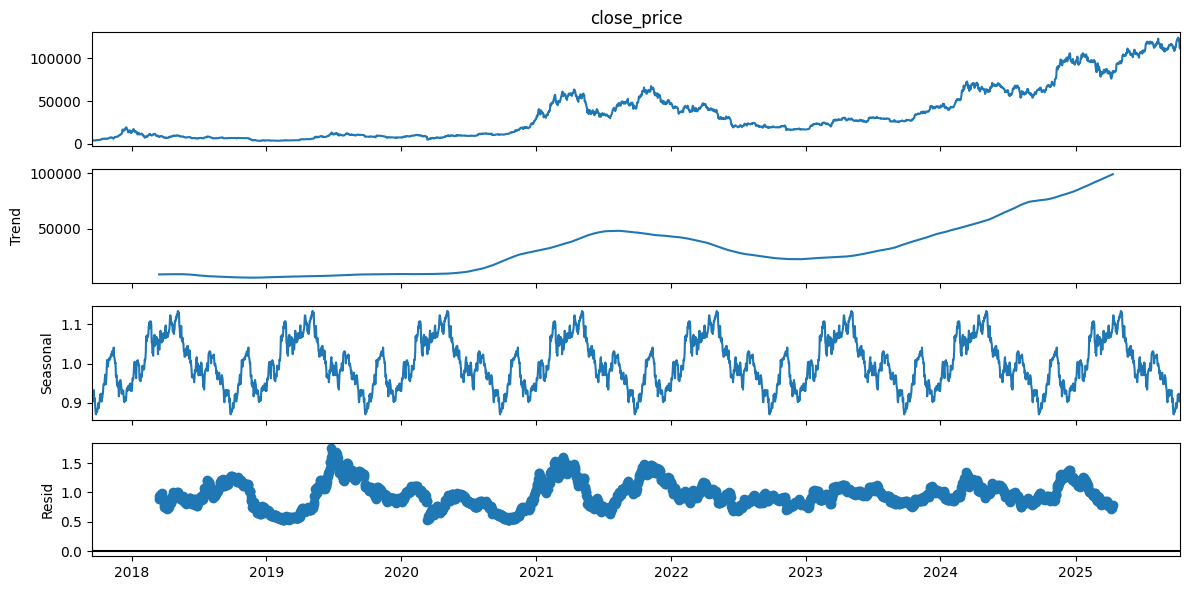

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df_daily["close_price"], model="multiplicative", period=365)
decompose.plot().show()

A trend is not always a straight line. In this graph as in (2018–2020) The trend is almost flat, which indicates a period of price stability where the long-term value was not growing significantly while in (2021 & 2024-) the trend line curves upward sharply, in (2022-2023) the trend line actually goes down where the long-term value was decreasing

So we can experiment Generalized Additive Model (GAM) to detect the non-linear trend.

In [25]:
from pygam import LinearGAM, s

# Create time index
t_train = np.arange(len(y_train)).reshape(-1, 1)

# Fit GAM
gam_basic = LinearGAM(s(0)).fit(t_train, y_train)
gam_best = LinearGAM(s(0)).gridsearch(t_train, y_train)

# extract trend
trend_gam_basic = gam_basic.predict(t_train)
trend_gam_best = gam_best.predict(t_train)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


In [26]:
# Decompose train series
decompose_train = seasonal_decompose(y_train, model="multiplicative", period=365)
trend_train = decompose_train.trend

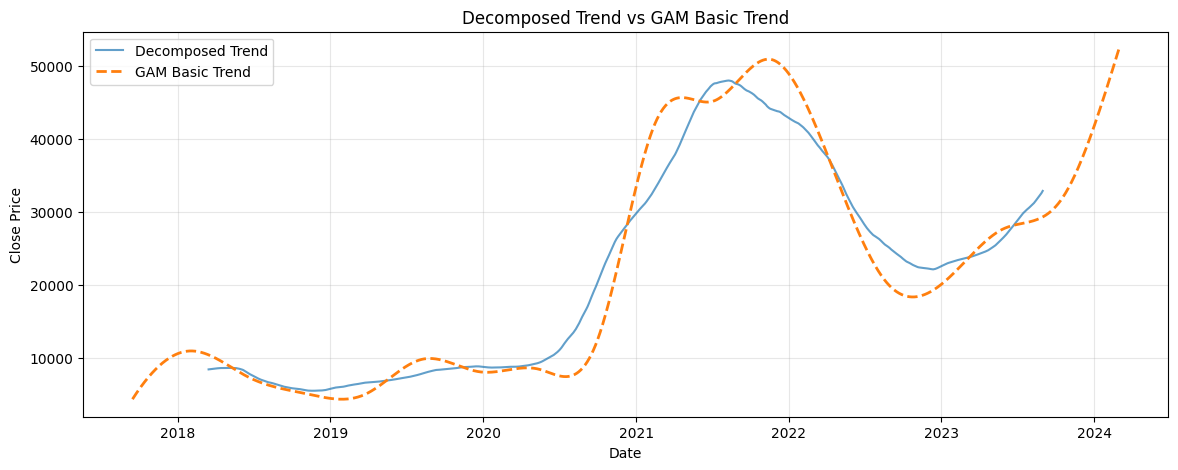

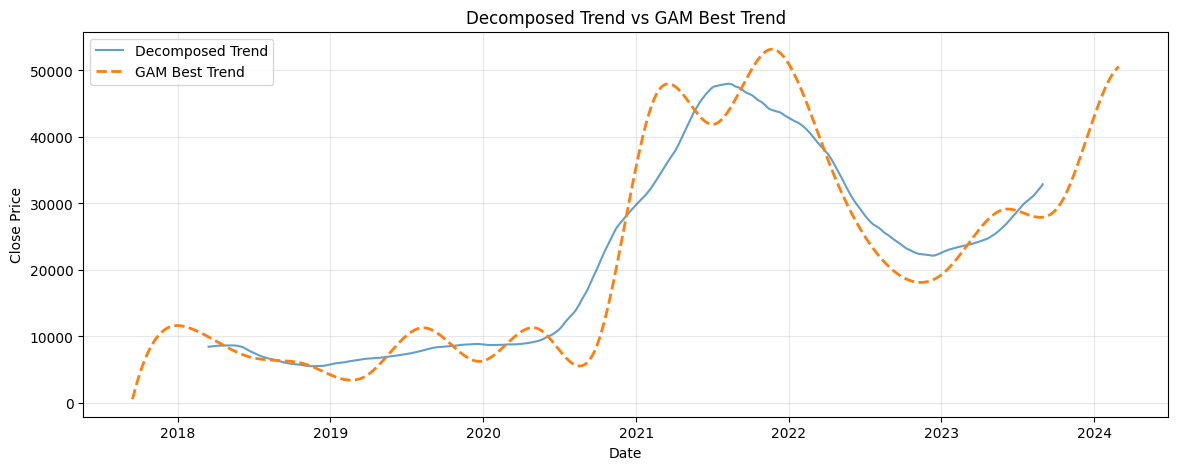

In [27]:
plot_trend_comparison(trend_train, trend_gam_basic, model_name="GAM Basic")
plot_trend_comparison(trend_train, trend_gam_best, model_name="GAM Best")

Using the GAM model and training it directly on y_train (the close prices), we observe that it effectively captures the non-linear trend and also adapts reasonably well to a portion of the residual fluctuations.

Although GAM can partially capture residual or seasonal patterns within the data, it still performs well overall. In some cases, applying GAM to the decomposed trend becomes challenging due to the presence of NaNs at the beginning and end of the series, as well as the need for careful alignment of the target variable before detrending. Therefore, we choose to fit the GAM model on the entire y_train. This approach allows the model to learn both the underlying trend and part of the residual behavior in a simpler and more robust way.

From the comparison between the basic (default) GAM model and the tuned GAM model, we can see that the tuned version captures the fluctuations more closely. However, our primary objective is trend extraction, not fitting short-term variations. Hence, a smoother trend (even if slightly less reactive) is often preferable for the hybrid modeling approach.

Next, we extract the trend using the GAM model and subtract it from y_train to obtain a stationary residual series. This detrended data is then used to train the XGBoost model using the optimal xgb_params obtained from grid search. This allows XGBoost to focus on modeling the residuals, ultimately improving performance and helping to mitigate extrapolation issues.

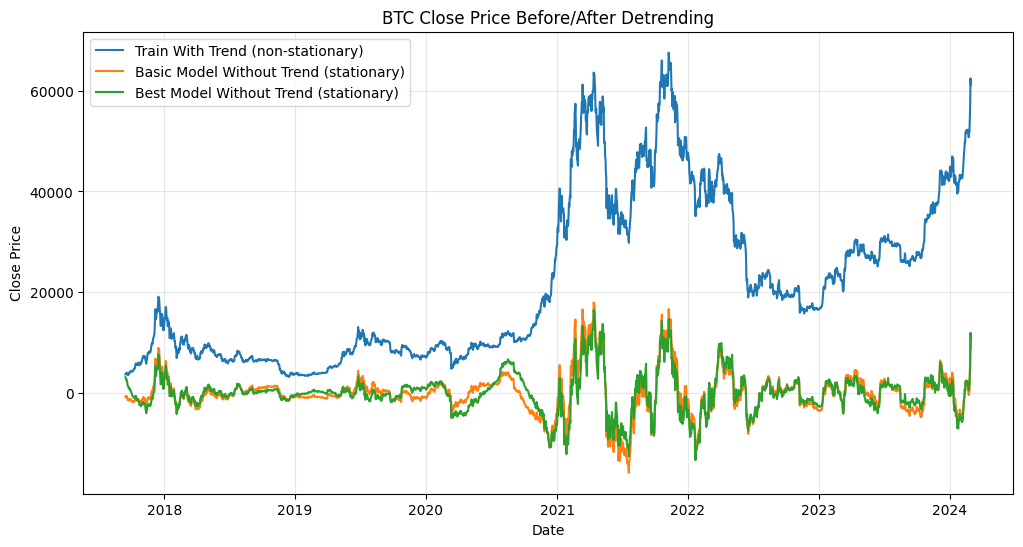

In [28]:
# Detrend
y_train_detrended_basic = y_train.values - trend_gam_basic
y_train_detrended_best = y_train.values - trend_gam_best

# Plot data after detrending
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actual data
ax.plot(X_train.index, y_train, label="Train With Trend (non-stationary)")
ax.plot(X_train.index, y_train_detrended_basic, label="Basic Model Without Trend (stationary)")
ax.plot(X_train.index, y_train_detrended_best, label="Best Model Without Trend (stationary)")

ax.set_title("BTC Close Price Before/After Detrending")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

### Hybrid Model

In [29]:
# Evaluate basic GAM
y_train_basic, y_test_basic, metrics_basic = evaluate_hybrid_model(
    gam_basic, X_train, y_train, X_test, y_test
)

# Evaluate tuned GAM
y_train_best, y_test_best, metrics_best = evaluate_hybrid_model(
    gam_best, X_train, y_train, X_test, y_test
)

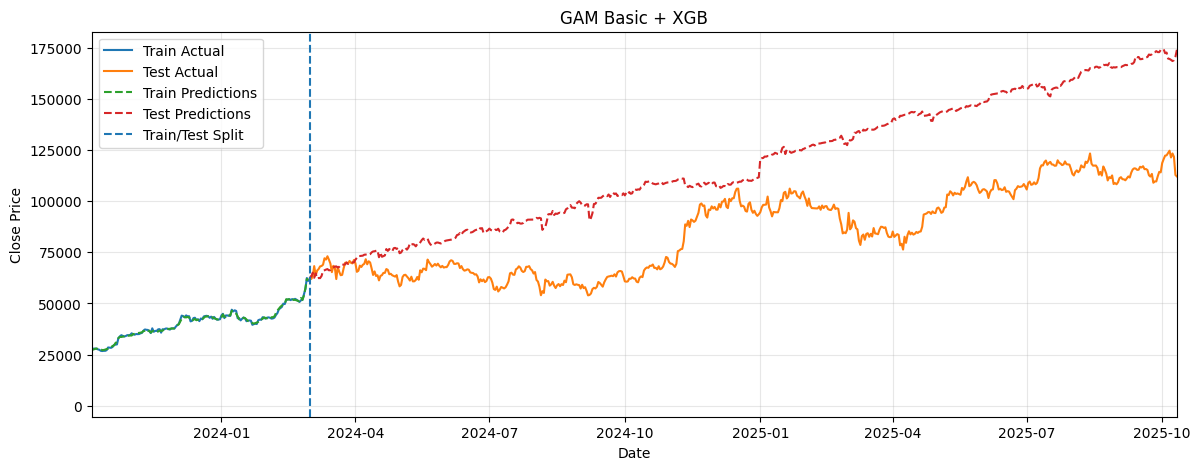

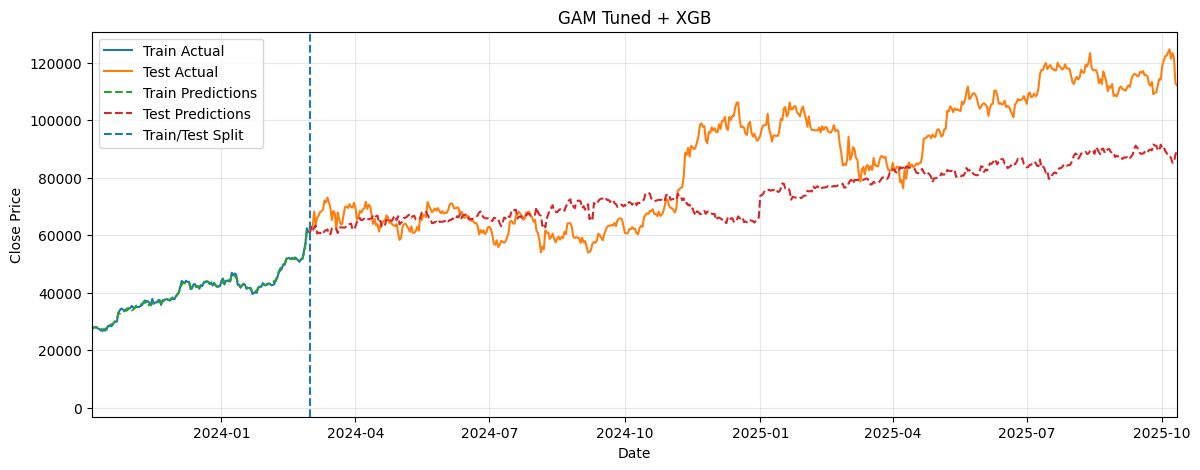

In [30]:
plot_time_series_split(
    X_train, y_train,
    X_test, y_test,
    y_pred=y_test_basic,
    y_train_pred=y_train_basic,
    zoom=True,
    zoom_pct=0.25,
    title="GAM Basic + XGB"
)

plot_time_series_split(
    X_train, y_train,
    X_test, y_test,
    y_pred=y_test_best,
    y_train_pred=y_train_best,
    zoom=True,
    zoom_pct=0.25,
    title="GAM Tuned + XGB"
)

This latest plot is a big improvement compared to the previous results. By using the hybrid approach (GAM for the trend + XGBoost for the residuals), we were able to solve the extrapolation problem that was clearly affecting the earlier models.

In the previous XGBoost-only model, the predictions were almost a flat horizontal line. Now, the predictions (red dashed line) are actually increasing. This is mainly because the GAM model was able to capture the long-term upward trend of Bitcoin. As a result, the model can now predict values higher than what it saw during training (like 140k–160k), which was not possible before.

At the same time, the predictions are not just a smooth curve. If we look closely at the red dashed line, we can see small fluctuations. These come from the XGBoost model, which is responsible for modeling the residuals and adding short-term movements on top of the GAM trend. This makes the predictions look more realistic and closer to actual price behavior.

However, even with this improvement, there is still a noticeable issue. We can see a gap between the actual values (orange) and the predictions (red), especially toward the end of 2024 and 2025. The model predicts a strong upward movement (almost reaching **175k**), while the actual price grows more slowly around 100k–120k. This suggests that the GAM overfitted the strong growth observed in late 2023 and early 2024 and assumed that this growth would continue at the same rate.

To address this, we moved a step further by applying Grid Search on top of the hybrid approach. This is an important step because it means we are no longer just trying models, but actually tuning the hyperparameters to achieve better performance.

After tuning, we can clearly see that the model behavior has improved. The predictions in the test set now look more stable and realistic. Previously, the model was too aggressive and was predicting very high values, but now it follows a more balanced upward trend for the 2024–2025 period. This improvement comes from finding better parameters (such as learning_rate and max_depth in XGBoost), which helped the model avoid blindly projecting extreme growth from the training data into the future.

Finally, the training performance remains strong. The predictions during the training period still align very closely with the actual values, which shows that the model has not lost its ability to learn historical patterns. At the same time, the smoother transition into the test set confirms that overfitting has been reduced compared to the earlier versions of the model.

In [31]:
comparison_df = pd.DataFrame([metrics_basic, metrics_best], 
                             index=["GAM Basic", "GAM Tuned"])

display(comparison_df)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train MAPE,Test MAPE
GAM Basic,338.881755,32659.760346,483.370876,36696.258682,0.999111,-2.164740,0.020692,0.384732
GAM Tuned,391.932367,14880.907592,544.084409,18619.991276,0.998873,0.185196,0.026736,0.157235


Despite the GAM model achieving very strong performance on the training data, both the basic and tuned versions exhibit significant degradation on the test set, as reflected by the high RMSE and negative R² scores. This indicates severe overfitting and poor generalization.

Interestingly, the tuned GAM model performs well compared to the default model on the test set. While tuning improves smoothness and reduces overfitting on the trend component, as it acheives better results on the **RMSE**, and acheiving positive result on the **R2 Score** with significant result on the MAPE Score.

These results suggest that the main limitation lies in the trend extrapolation capability of the GAM model, as it struggles to generalize beyond the training range. Consequently, errors in trend estimation propagate to the final predictions, negatively impacting overall performance.

So we will try another regression model to extract only the trend without residuals or patterns from the data so that we extract the trend from the data and keep the residuals for the tree based model.

#### Other Regressors for Deterending

In [34]:
trend_train, lr_trend, lr_model = fit_trend_model(y_train, seasonality_model="multiplicative", model_type="linear")
_, svm_trend, svm_model = fit_trend_model(y_train, model_type="svm", seasonality_model="multiplicative", period=365, kernel="poly")

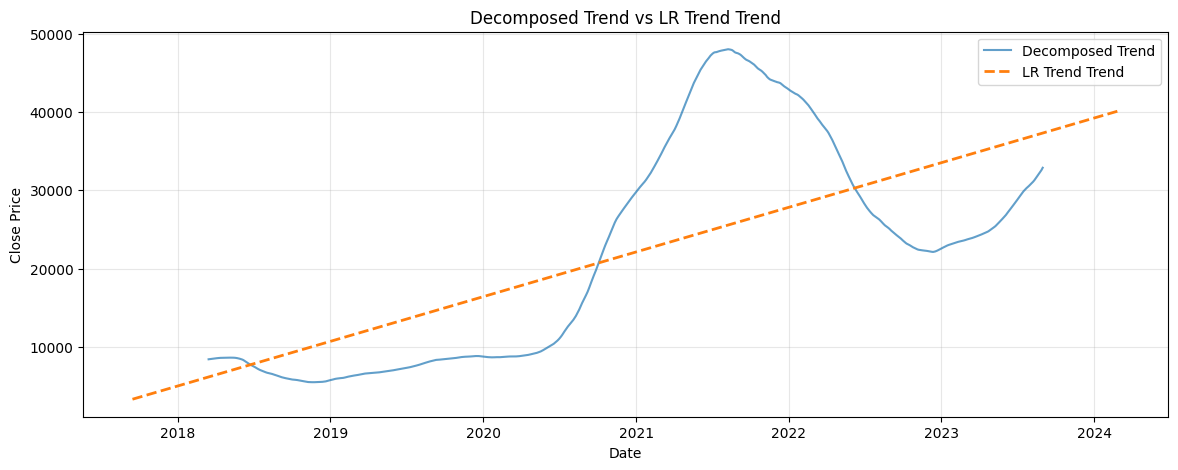

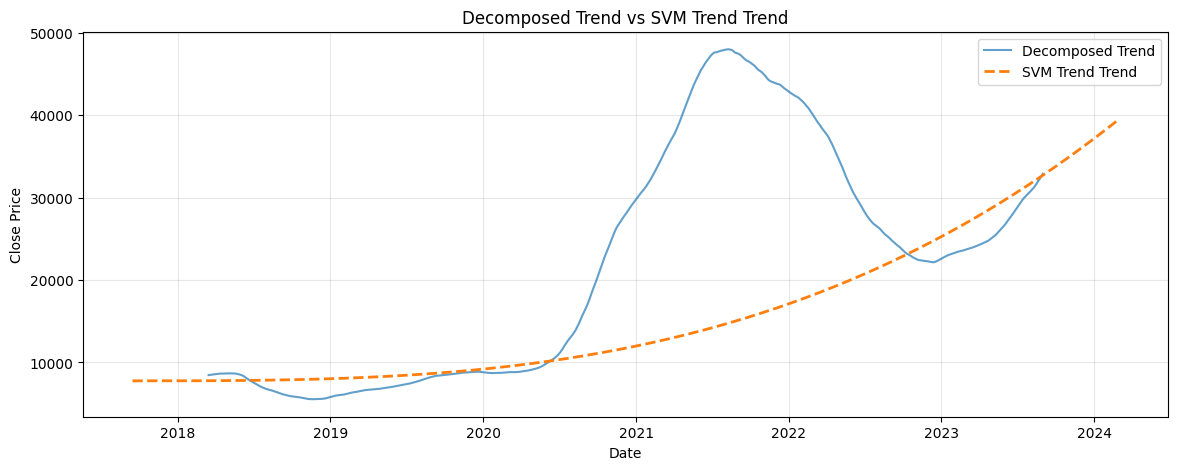

In [35]:
plot_trend_comparison(trend_train, lr_trend, model_name="LR Trend")
plot_trend_comparison(trend_train, svm_trend, model_name="SVM Trend")

As mentioned before, the trend is not linear, so the Linear Regression model could not capture the non-linearity in the data. The SVM model with a polynomial kernel performed slightly better, but it remained almost linear for the first three years and only increased afterward. It still failed to capture the peaks and downward movements in the close prices accurately.

In [36]:
# Evaluate basic SVM
y_train_svm, y_test_svm, metrics_svm = evaluate_hybrid_model(
    svm_model, X_train, y_train, X_test, y_test
)

# Evaluate LR
y_train_lr, y_test_lr, metrics_lr = evaluate_hybrid_model(
    lr_model, X_train, y_train, X_test, y_test
)

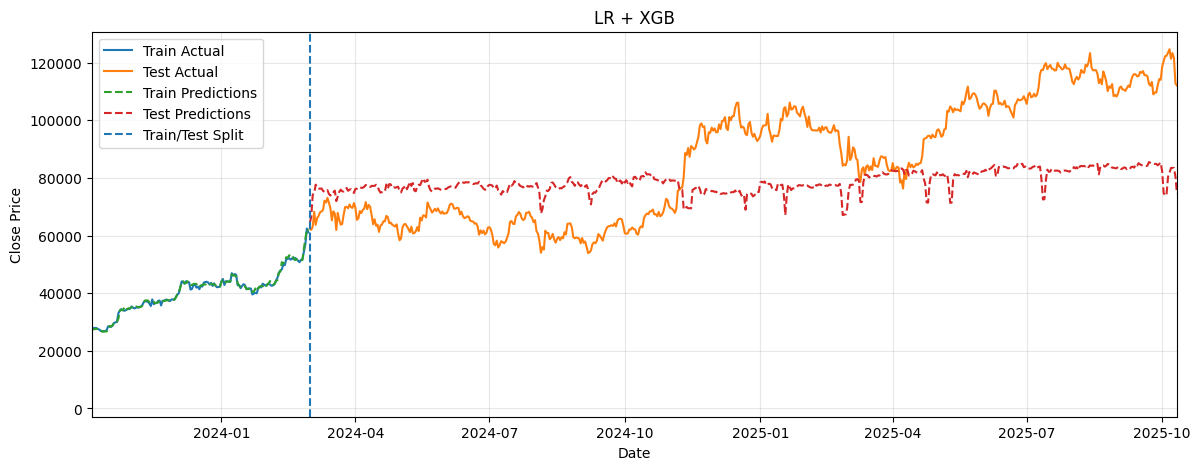

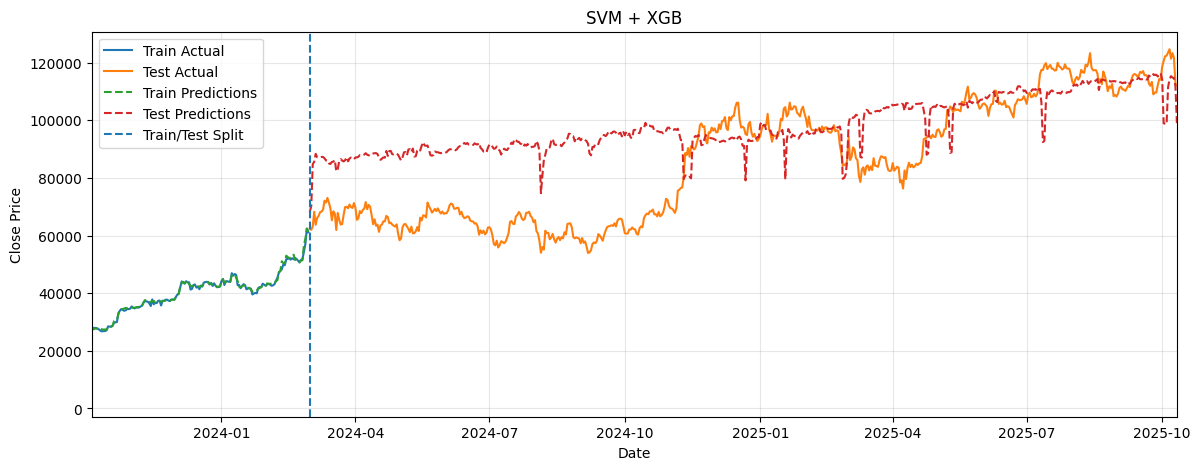

In [37]:
plot_time_series_split(
    X_train, y_train,
    X_test, y_test,
    y_pred=y_test_lr,
    y_train_pred=y_train_lr,
    zoom=True,
    zoom_pct=0.25,
    title="LR + XGB"
)

plot_time_series_split(
    X_train, y_train,
    X_test, y_test,
    y_pred=y_test_svm,
    y_train_pred=y_train_svm,
    zoom=True,
    zoom_pct=0.25,
    title="SVM + XGB"
)

### Comparing All Hybrid ML Models

In [38]:
comparison_df = pd.DataFrame([metrics_svm, metrics_lr, metrics_basic, metrics_best], 
                             index=["SVM + XGB", "Linear Regression + XGB", "GAM Basic + XGB", "Gam Tuned + XGB"])

display(comparison_df)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train MAPE,Test MAPE
SVM + XGB,380.966386,15320.768112,540.569596,19175.722883,0.998888,0.135832,0.024061,0.220541
Linear Regression + XGB,553.282778,18093.260676,814.064537,20404.604433,0.997477,0.021523,0.041100,0.206328
GAM Basic + XGB,338.881755,32659.760346,483.370876,36696.258682,0.999111,-2.164740,0.020692,0.384732
Gam Tuned + XGB,391.932367,14880.907592,544.084409,18619.991276,0.998873,0.185196,0.026736,0.157235


We compared several hybrid models that combine a trend estimator with XGBoost on the residuals. 

The **Fine Tuned GAM** + **XGBoost** combination performed very well on the test set: **GAM** captured the main trend, leaving **XGBoost** to model the residuals effectively, which led to good generalization. 

The **Linear Regression** + **XGBoost** model had moderate test performance. The linear trend could not fully capture non-linear behavior, but XGBoost helped by modeling the residuals. The GAM Basic + XGBoost model fit the training data almost perfectly, but test performance suffered. 

Here, Basic GAM overfitted the trend, and XGBoost ended up learning residuals that included this overfit noise, resulting in negative test R². Over-tuning GAM made this much better.

The key takeaway is that the trend extraction step must avoid overfitting. If the trend model overfits, the residuals are polluted with overfit signals, making it harder for XGBoost to learn meaningful short-term patterns. A clean trend extraction is essential for a hybrid model to work well.

Based on this, we will stick with the **Fine Tuned GAM** for trend prediction and use it in a hybrid model alongside **XGBoost**.